# Elementos finitos com FEniCSx/dolfinx

Esta pasta reúne a versão das aulas em `dolfinx`, mantendo a mesma filosofia
das aulas em Firedrake: partir da modelagem matemática, obter a formulação
variacional, escolher os espaços discretos e só então traduzir a formulação em
código.

A sequência de notebooks é:

1. Poisson escalar com solução manufaturada.
2. Elasticidade linear em pequenas deformações.
3. Equação do calor com discretização temporal implícita.
4. Sistema de reação-difusão de Gray-Scott.

## Roteiro conceitual das aulas

Em praticamente todos os exemplos vamos seguir o mesmo roteiro:

1. escrever a **forma forte** do problema;
2. escolher funções-teste adequadas;
3. integrar por partes quando necessário;
4. identificar as condições de contorno essenciais e naturais;
5. escolher um espaço discreto $V_h$ ou $W_h$;
6. montar a forma bilinear, linear ou não linear;
7. resolver o sistema algébrico resultante;
8. visualizar a solução e checar diagnósticos numéricos simples.

Essa repetição é intencional: em um curso de implementação, a consistência do
procedimento ajuda a separar o que é modelagem, o que é análise variacional e
o que é detalhe de API.

## Convenções adotadas

- Os notebooks foram pensados para execução em uma única tarefa MPI, como
  ocorre tipicamente no JupyterLab.
- As malhas e os passos de tempo foram escolhidos para rodar bem em aula; isso
  não substitui estudos de convergência ou de estabilidade mais amplos.
- Nos notebooks em `dolfinx`, o controle de threads do BLAS/OpenMP aparece
  antes do `numpy`. Isso evita oversubscription e torna a execução bem mais
  previsível em notebooks.
- O LaTeX em markdown foi escrito com MathJax em mente, priorizando a forma
  `$...$` e `$$...$$`, que tende a renderizar de maneira mais estável em
  Jupyter e VS Code.

In [1]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

from mpi4py import rc

rc.finalize = False

from mpi4py import MPI
from petsc4py import PETSc

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import dolfinx
import ufl
from dolfinx import mesh, plot

## Teste mínimo de importação

Se esta célula executa corretamente no ambiente `fenics-env`, já sabemos que a
pilha principal do notebook está disponível.

In [2]:
print("dolfinx:", dolfinx.__version__)
print("ufl:", ufl.__version__)
print("MPI size:", MPI.COMM_WORLD.size)
print("PETSc scalar type:", PETSc.ScalarType)
print("Threads OpenMP:", os.environ["OMP_NUM_THREADS"])

dolfinx: 0.11.0
ufl: 2026.1.0
MPI size: 1
PETSc scalar type: <class 'numpy.float64'>
Threads OpenMP: 1


## Primeiro gráfico: a malha como objeto geométrico

Antes de resolver qualquer PDE, vale lembrar que o método de elementos finitos
começa pela discretização do domínio. A figura abaixo mostra uma malha
triangular simples da unidade quadrada.

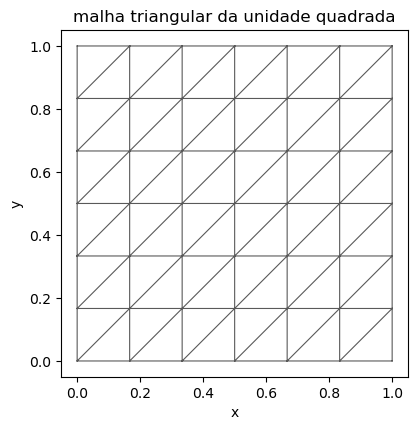

In [3]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, 6, 6)
topology, _, geometry = plot.vtk_mesh(domain, domain.topology.dim)
triangles = topology.reshape((-1, 4))[:, 1:]
triangulation = mtri.Triangulation(geometry[:, 0], geometry[:, 1], triangles)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.triplot(triangulation, color="0.35", lw=0.8)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("malha triangular da unidade quadrada")
plt.show()

## Observações importantes para o restante das aulas

1. Quando escrevemos $V_h \\subset H^1(\\Omega)$, a implementação em `dolfinx`
   aparece como um `functionspace`.
2. Quando escrevemos uma forma como
   $$
   a(u, v) = \int_\Omega \nabla u \cdot \nabla v \, dx,
   $$
   a tradução computacional vem via UFL, por exemplo
   `inner(grad(u), grad(v)) * dx`.
3. A montagem do sistema e a solução linear ou não linear são delegadas a
   PETSc, mas a estrutura matemática do problema continua visível no código.

Em outras palavras: a biblioteca resolve a parte algébrica pesada, mas a
responsabilidade pela formulação continua sendo nossa.